# 06d - Strict temporal retrieval and corpus-gap audit

**Notebook version: 06d-rag-temporal-v3**

06d 是进入付费 LLM 评测前的最后一轮本地检索审计。它不调用 API 或 LLM。

本版解决四个问题：

1. 每个审计日期单独拟合 TF-IDF，只让词表和 IDF 看到当时已经发布的资料；
2. 使用 PDF 文字坐标分离 manifesto 的左右栏，避免同一 chunk 混入两个栏目；
3. 不再凑满八条证据，只保留达到绝对门槛和相对门槛的证据；
4. 区分 query-definition gap 与 corpus gap，输出需要补充语料的政党、领域和来源类型。

06d 继续使用 06c 的同一组24个 post-election Validation divisions。Train 仍然作为历史证据，不作为主审计问题。

## 1. Imports and configuration

In [1]:
# 导入坐标提取、滚动检索、审计和绘图需要的库。
from pathlib import Path
from collections import defaultdict
import ast
import hashlib
import re
import shutil
import subprocess
import warnings

from bs4 import BeautifulSoup
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 240)
pd.set_option('display.max_colwidth', 220)

NOTEBOOK_VERSION = '06d-rag-temporal-v3'
RANDOM_STATE = 42
PARTIES = ['conservative', 'green', 'labour', 'liberal-democrat']
TARGET = 'target_binary_support'

# 查询字段权重只作用于检索向量，不修改原始文本。
QUERY_MOTION_MAX_CHARS = 1800
TITLE_REPEAT = 4
POLICY_OBJECT_REPEAT = 5
LEGISLATION_REPEAT = 3
DOMAIN_REPEAT = 1

# Manifesto按栏位分块，不跨页面或栏位合并。
MANIFESTO_BLOCK_TARGET = 1050
MANIFESTO_BLOCK_MIN = 120
MANIFESTO_LARGE_BLOCK_SIZE = 1200
MANIFESTO_LARGE_BLOCK_OVERLAP = 120

# 历史记录按正文切分，但检索文本不包含标签模板。
HISTORICAL_CHUNK_SIZE = 1400
HISTORICAL_CHUNK_OVERLAP = 160

# 每种来源使用独立门槛，并且不再强制补足八条。
MAX_RESULTS = 8
MAX_POLICY_RESULTS = 2
MAX_HISTORICAL_RESULTS = 4
MAX_BILL_RESULTS = 1
MAX_CHUNKS_PER_DOCUMENT = 2
POLICY_ABS_MIN = 0.025
POLICY_RELATIVE_TO_TOP = 0.60
HISTORICAL_BASE_MIN = 0.055
HISTORICAL_RELATIVE_TO_TOP = 0.72
HISTORICAL_TITLE_OVERLAP_MIN = 0.08
HISTORICAL_STRONG_BASE = 0.095
BILL_ABS_MIN = 0.095
DOMAIN_MATCH_BOOST = 0.015
TITLE_OVERLAP_WEIGHT = 0.060

ROOT = Path.cwd()
MODEL_DIR = ROOT / 'processed' / 'model_v2'
RAG_V1_DIR = ROOT / 'processed' / 'rag_v1'
AUDIT_V2_DIR = ROOT / 'processed' / 'rag_audit_v2'
RAG_V3_DIR = ROOT / 'processed' / 'rag_v3'
AUDIT_V3_DIR = ROOT / 'processed' / 'rag_audit_v3'
RAG_V3_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_V3_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = MODEL_DIR / 'model_train_v2.csv'
VALIDATION_PATH = MODEL_DIR / 'model_validation_v2.csv'
TEST_PATH = MODEL_DIR / 'model_test_v2.csv'
SOURCE_REGISTRY_PATH = RAG_V1_DIR / 'official_policy_source_registry.csv'
AUDIT_SAMPLE_PATH = AUDIT_V2_DIR / 'audit_divisions_v2.csv'
V2_EVIDENCE_PATH = AUDIT_V2_DIR / 'retrieval_v2_evidence.csv'
BILL_INFO_PATH = ROOT / 'data' / 'raw' / 'bill_info.csv'

print('Notebook version:', NOTEBOOK_VERSION)
print('API calls enabled: False')
print('LLM calls enabled: False')
print('Rolling temporal TF-IDF enabled: True')

Notebook version: 06d-rag-temporal-v3
API calls enabled: False
LLM calls enabled: False
Rolling temporal TF-IDF enabled: True


## 2. Load inputs and reuse the exact 06c audit sample

06d 不重新抽样，而是读取06c保存的24条 division 清单。这样v2与v3差异来自检索变化，而不是样本变化。

In [2]:
# 检查输入文件并读取模型数据、来源登记表和审计样本。
required_paths = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    SOURCE_REGISTRY_PATH,
    AUDIT_SAMPLE_PATH,
    BILL_INFO_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('缺少必要文件：\n' + '\n'.join(missing_paths))

train = pd.read_csv(TRAIN_PATH, parse_dates=['motion_date'])
validation = pd.read_csv(VALIDATION_PATH, parse_dates=['motion_date'])
test_keys = pd.read_csv(TEST_PATH, usecols=['division_key'])
source_registry = pd.read_csv(
    SOURCE_REGISTRY_PATH,
    parse_dates=['published_at'],
)
bill_info = pd.read_csv(BILL_INFO_PATH, low_memory=False)
audit_sample_keys = pd.read_csv(
    AUDIT_SAMPLE_PATH,
    parse_dates=['motion_date'],
)

development_votes = pd.concat([
    train.assign(source_split='train'),
    validation.assign(source_split='validation'),
], ignore_index=True)
development_votes = development_votes[
    development_votes[TARGET].notna()
].copy()

query_columns = [
    'division_key', 'motion_date', 'motion_title_clean', 'motion_text_clean',
    'motion_type', 'motion_family', 'policy_domain_primary',
    'policy_domain_labels', 'policy_domain_count', 'final_policy_object',
    'legislation_name_clean', 'motion_char_count',
]
audit_divisions = (
    audit_sample_keys[['division_key', 'sampling_stage', 'audit_order']]
    .merge(
        validation[query_columns].drop_duplicates('division_key'),
        on='division_key',
        how='left',
        validate='one_to_one',
    )
    .sort_values('audit_order')
    .reset_index(drop=True)
)

assert len(audit_divisions) == 24
assert audit_divisions['division_key'].is_unique
assert audit_divisions['motion_date'].notna().all()
assert not set(development_votes['division_key']) & set(test_keys['division_key'])

display(audit_divisions[[
    'audit_order', 'sampling_stage', 'division_key', 'motion_date',
    'motion_title_clean', 'final_policy_object',
    'policy_domain_primary', 'policy_domain_count',
]])

,audit_order,sampling_stage,division_key,motion_date,motion_title_clean,final_policy_object,policy_domain_primary,policy_domain_count
0,1,domain_stratified,pw-2024-07-23-2-commons,2024-07-23,Amendment: Immigration and Home Affairs,NaN,agriculture_food_rural,7
1,2,domain_stratified,pw-2024-07-23-3-commons,2024-07-23,Immigration and Home Affairs,NaN,welfare_pensions_poverty,4
2,3,domain_stratified,pw-2024-07-23-4-commons,2024-07-23,Immigration and Home Affairs,NaN,education_skills_children,5
3,4,domain_stratified,pw-2024-07-25-5-commons,2024-07-25,Approve: Criminal Justice Act 2003 (Requisite and Minimum Custodial Periods) Order 2024,NaN,justice_crime_policing,1
4,5,domain_stratified,pw-2024-07-29-6-commons,2024-07-29,Second Reading: Passenger Railway Services (Public Ownership) Bill,NaN,transport_infrastructure,1
5,6,domain_stratified,pw-2024-09-03-7-commons,2024-09-03,Clause 2 - Future provision of services,"Proposed amendment to Clause 2 - Future provision of services: Amendment proposed: 14, page 2, line 17, at end insert (1BA) Every contract made in accordance with subsection (1A) shall place a duty on the public sect...",transport_infrastructure,3
6,7,random_fill,pw-2024-09-05-13-commons,2024-09-05,Second Reading: Great British Energy Bill,NaN,environment_energy_water,1
7,8,domain_stratified,pw-2024-09-10-14-commons,2024-09-10,Social Security,NaN,welfare_pensions_poverty,1
8,9,domain_stratified,pw-2024-10-08-16-commons,2024-10-08,VAT: Independent Schools,VAT on independent-school fees,education_skills_children,5
9,10,domain_stratified,pw-2024-10-08-17-commons,2024-10-08,Farming and Food Security,Continuation and full use of the stated farming support funds and farming budget,agriculture_food_rural,5


## 3. Shared text and scoring helpers

In [3]:
# 定义缺失值处理、文本清理、分块、哈希和重叠率函数。
def safe_text(value):
    # 把缺失值安全转换为空字符串。
    if value is None or pd.isna(value):
        return ''
    return str(value).strip()


def clean_text(value):
    # 保留有效换行，同时压缩重复空格和空行。
    value = safe_text(value).replace('\x00', ' ')
    lines = [re.sub(r'\s+', ' ', line).strip() for line in value.splitlines()]
    lines = [line for line in lines if line]
    return '\n'.join(lines)


def split_text(text, chunk_size, overlap):
    # 优先在靠近长度上限的换行、句号或空格处切分。
    text = clean_text(text)
    if not text:
        return []
    if len(text) <= chunk_size:
        return [(0, len(text), text)]

    parts = []
    start = 0
    while start < len(text):
        target_end = min(start + chunk_size, len(text))
        end = target_end
        if target_end < len(text):
            candidates = [
                text.rfind('\n', start + chunk_size // 2, target_end),
                text.rfind('. ', start + chunk_size // 2, target_end),
                text.rfind(' ', start + chunk_size // 2, target_end),
            ]
            valid = [position for position in candidates if position > start]
            if valid:
                end = max(valid) + 1

        body = text[start:end].strip()
        if body:
            parts.append((start, end, body))
        if end >= len(text):
            break
        next_start = max(0, end - overlap)
        start = end if next_start <= start else next_start
    return parts


def make_chunk_id(document_id, chunk_index, retrieval_text):
    # 使用稳定哈希生成可重复的chunk ID。
    digest = hashlib.sha256(
        f'{document_id}|{chunk_index}|{retrieval_text}'.encode('utf-8')
    ).hexdigest()[:20]
    return f'chunk_v3_{digest}'


def word_set(value):
    # 提取至少两个字符的英文与数字词。
    return set(re.findall(r'[a-z0-9][a-z0-9\-]{1,}', safe_text(value).lower()))


def jaccard_overlap(left, right):
    # 计算两个词集合的Jaccard重叠率。
    left_words = word_set(left)
    right_words = word_set(right)
    union = left_words | right_words
    if not union:
        return 0.0
    return len(left_words & right_words) / len(union)


def repeat_field(value, times):
    # 通过重复字段提高它在TF-IDF查询向量中的权重。
    value = clean_text(value)
    return '\n'.join([value] * times) if value else ''


def parse_stage_description(value):
    # 安全解析Bill阶段字典，只保留可读说明。
    if value is None or pd.isna(value):
        return ''
    if isinstance(value, dict):
        return safe_text(value.get('description'))
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return ''
    return safe_text(parsed.get('description')) if isinstance(parsed, dict) else ''


def normalise_heading(value):
    # 为栏目标题删除多余标点和换行。
    value = clean_text(value).replace('\n', ' ')
    return re.sub(r'\s+', ' ', value).strip(' -|')

## 4. Extract manifesto blocks using PDF coordinates

`pdftotext -bbox-layout` 会返回每个文字块的页面坐标。06d 不把整页直接拼成一段，而是：

1. 读取每个 block 的 `xMin/xMax/yMin/yMax`；
2. 按页面中点把窄 block 分为 left 与 right；
3. 宽度超过页面65%的 block 标记为 full；
4. 只在同一页面、同一栏位内合并短 block；
5. 大 block 单独切分，不与另一栏文字混合。

这样可以处理Green等双栏或跨页式排版。

In [4]:
# 使用Poppler坐标输出解析manifesto的页面、栏位和文字块。
PDF_NOISE = {
    'real hope.',
    'real change.',
    're al hope.',
    're al change.',
}


def clean_manifesto_block(value):
    # 删除纯页码、口号、印刷说明和过短噪声行。
    lines = []
    for raw_line in safe_text(value).splitlines():
        line = re.sub(r'\s+', ' ', raw_line).strip()
        lowered = line.lower()
        if not line:
            continue
        if lowered in PDF_NOISE:
            continue
        if re.fullmatch(r'\d{1,3}', line):
            continue
        if lowered.startswith('promoted by '):
            continue
        if lowered.startswith('printed by '):
            continue
        lines.append(line)
    return '\n'.join(lines)


def bbox_pages(path):
    # 调用pdftotext的bbox-layout模式并返回页面级文字块。
    executable = shutil.which('pdftotext')
    if not executable:
        raise RuntimeError('未找到pdftotext，请安装Poppler后重试。')
    result = subprocess.run(
        [executable, '-bbox-layout', str(path), '-'],
        check=True,
        capture_output=True,
        text=True,
    )
    soup = BeautifulSoup(result.stdout, 'html.parser')
    pages = []

    for page_number, page in enumerate(soup.find_all('page'), start=1):
        page_width = float(page.get('width', 0) or 0)
        midpoint = page_width / 2 if page_width else 0
        page_blocks = []

        for block_index, block in enumerate(page.find_all('block')):
            x_min = float(block.get('xmin', 0) or 0)
            x_max = float(block.get('xmax', 0) or 0)
            y_min = float(block.get('ymin', 0) or 0)
            y_max = float(block.get('ymax', 0) or 0)
            line_texts = []
            for line in block.find_all('line'):
                words = [word.get_text(' ', strip=True) for word in line.find_all('word')]
                line_text = ' '.join(word for word in words if word)
                if line_text:
                    line_texts.append(line_text)
            text = clean_manifesto_block('\n'.join(line_texts))
            if not text or len(text) < 12:
                continue

            width = max(0.0, x_max - x_min)
            center = (x_min + x_max) / 2
            if page_width and width >= 0.65 * page_width:
                column = 'full'
            elif midpoint and center < midpoint:
                column = 'left'
            else:
                column = 'right'

            page_blocks.append({
                'page_number': page_number,
                'block_index': block_index,
                'column': column,
                'x_min': x_min,
                'x_max': x_max,
                'y_min': y_min,
                'y_max': y_max,
                'text': text,
            })
        pages.append(page_blocks)
    return pages


def heading_candidate(text):
    # 从短文字块中提取可能的章节标题。
    first_line = normalise_heading(safe_text(text).split('\n')[0])
    word_count = len(first_line.split())
    if 2 <= word_count <= 14 and len(first_line) <= 110:
        if not first_line.endswith(('.', ';', ':')):
            return first_line
    return ''


def merge_same_column_blocks(page_blocks):
    # 只在同一栏位内合并相邻短块，绝不跨栏位合并。
    merged = []
    for column in ['full', 'left', 'right']:
        column_blocks = sorted(
            [block for block in page_blocks if block['column'] == column],
            key=lambda block: (block['y_min'], block['x_min']),
        )
        buffer = []
        buffer_chars = 0
        active_heading = ''

        def flush_buffer():
            # 把当前栏位缓冲区保存为一个逻辑段。
            nonlocal buffer, buffer_chars, active_heading
            if not buffer:
                return
            body = clean_text('\n'.join(item['text'] for item in buffer))
            if body:
                merged.append({
                    'column': column,
                    'y_min': min(item['y_min'] for item in buffer),
                    'y_max': max(item['y_max'] for item in buffer),
                    'heading': active_heading,
                    'text': body,
                })
            buffer = []
            buffer_chars = 0

        for block in column_blocks:
            possible_heading = heading_candidate(block['text'])
            if possible_heading and len(block['text']) <= 180:
                flush_buffer()
                active_heading = possible_heading
                buffer = [block]
                buffer_chars = len(block['text'])
                continue

            projected = buffer_chars + len(block['text']) + 1
            if buffer and projected > MANIFESTO_BLOCK_TARGET:
                flush_buffer()
            buffer.append(block)
            buffer_chars += len(block['text']) + 1
        flush_buffer()
    return merged


manifesto_rows = []
manifesto_layout_audit = []

for _, source in source_registry.iterrows():
    local_path = Path(source['local_path'])
    if not local_path.exists():
        raise FileNotFoundError(f'未找到官方政策文件：{local_path}')

    pages = bbox_pages(local_path)
    document_id = safe_text(source['document_id'])
    chunk_index = 0
    column_counts = defaultdict(int)

    for page_number, page_blocks in enumerate(pages, start=1):
        logical_blocks = merge_same_column_blocks(page_blocks)
        for logical_block in logical_blocks:
            column_counts[logical_block['column']] += 1
            heading = logical_block['heading'] or f'Page {page_number}'
            for _, _, body in split_text(
                logical_block['text'],
                chunk_size=MANIFESTO_LARGE_BLOCK_SIZE,
                overlap=MANIFESTO_LARGE_BLOCK_OVERLAP,
            ):
                if len(body) < MANIFESTO_BLOCK_MIN:
                    continue
                evidence_title = (
                    f"{source['title']} | {heading}"
                )
                retrieval_text = clean_text('\n'.join([
                    repeat_field(heading, 2),
                    body,
                ]))
                manifesto_rows.append({
                    'chunk_id': make_chunk_id(
                        document_id, chunk_index, retrieval_text
                    ),
                    'document_id': document_id,
                    'chunk_index': chunk_index,
                    'party': source['party'],
                    'source_type': 'manifesto',
                    'title': evidence_title,
                    'source_url': source['url'],
                    'source_date': source['published_at'],
                    'division_key': pd.NA,
                    'motion_type': pd.NA,
                    'motion_family': pd.NA,
                    'policy_domain': pd.NA,
                    'stance_label': pd.NA,
                    'page_number': page_number,
                    'page_column': logical_block['column'],
                    'retrieval_text': retrieval_text,
                    'evidence_text': body,
                })
                chunk_index += 1

    manifesto_layout_audit.append({
        'document_id': document_id,
        'party': source['party'],
        'pages': len(pages),
        'chunks': chunk_index,
        'full_blocks': column_counts['full'],
        'left_blocks': column_counts['left'],
        'right_blocks': column_counts['right'],
    })

manifesto_chunks = pd.DataFrame(manifesto_rows)
manifesto_layout_audit = pd.DataFrame(manifesto_layout_audit)
display(manifesto_layout_audit)

,document_id,party,pages,chunks,full_blocks,left_blocks,right_blocks
0,manifesto_2024_labour,labour,136,303,69,295,241
1,manifesto_2024_conservative,conservative,80,291,9,233,176
2,manifesto_2024_liberal_democrat,liberal-democrat,135,332,1264,157,0
3,manifesto_2024_green,green,28,244,1,277,352


## 5. Build historical-vote and Bill chunks

历史投票的 `retrieval_text` 只包含标题、正文和 legislation。Party与stance保留在元数据和`evidence_text`中，但不参与TF-IDF词权重。

Bill只保留title、long title和summary；完整的阶段字典不进入检索文本。

In [5]:
# 建立历史投票与Bill检索块。
historical_rows = []
for _, row in development_votes.iterrows():
    title = clean_text(row.get('motion_title_clean'))
    motion_text = clean_text(row.get('motion_text_clean'))
    legislation = clean_text(row.get('legislation_name_clean'))
    stance = 'support' if int(row[TARGET]) == 1 else 'oppose'
    document_id = f"historical_vote_{row['row_id']}"

    for chunk_index, (_, _, body) in enumerate(split_text(
        motion_text or title,
        chunk_size=HISTORICAL_CHUNK_SIZE,
        overlap=HISTORICAL_CHUNK_OVERLAP,
    )):
        retrieval_text = clean_text('\n'.join([
            repeat_field(title, 2),
            body,
            legislation,
        ]))
        evidence_text = clean_text(
            f'Historical parliamentary vote.\n'
            f"Party: {row['party']}.\n"
            f'Observed stance: {stance}.\n'
            f'Motion title: {title}.\n'
            f'Motion text: {body}.\n'
            f'Legislation: {legislation}.'
        )
        historical_rows.append({
            'chunk_id': make_chunk_id(
                document_id, chunk_index, retrieval_text
            ),
            'document_id': document_id,
            'chunk_index': chunk_index,
            'party': row['party'],
            'source_type': 'historical_vote',
            'title': title,
            'source_url': pd.NA,
            'source_date': row['motion_date'],
            'division_key': row['division_key'],
            'motion_type': row.get('motion_type', pd.NA),
            'motion_family': row.get('motion_family', pd.NA),
            'policy_domain': row.get('policy_domain_primary', pd.NA),
            'stance_label': stance,
            'page_number': pd.NA,
            'page_column': pd.NA,
            'retrieval_text': retrieval_text,
            'evidence_text': evidence_text,
        })

historical_chunks = pd.DataFrame(historical_rows)

bill_rows = []
for _, row in bill_info.iterrows():
    bill_id = safe_text(row.get('billId'))
    title = clean_text(row.get('shortTitle')) or clean_text(row.get('longTitle'))
    long_title = clean_text(row.get('longTitle'))
    summary = clean_text(row.get('summary'))
    stage = parse_stage_description(row.get('currentStage'))
    source_date = pd.to_datetime(row.get('lastUpdate'), errors='coerce')
    document_id = f'bill_{bill_id or len(bill_rows)}'
    full_text = clean_text('\n'.join([title, title, long_title, summary]))
    if not full_text:
        continue

    for chunk_index, (_, _, body) in enumerate(split_text(
        full_text,
        chunk_size=HISTORICAL_CHUNK_SIZE,
        overlap=HISTORICAL_CHUNK_OVERLAP,
    )):
        evidence_text = clean_text(
            f'Bill reference.\n'
            f'Bill title: {title}.\n'
            f'Long title: {long_title}.\n'
            f'Summary: {summary}.\n'
            f'Current stage: {stage}.'
        )
        bill_rows.append({
            'chunk_id': make_chunk_id(document_id, chunk_index, body),
            'document_id': document_id,
            'chunk_index': chunk_index,
            'party': 'all',
            'source_type': 'bill_reference',
            'title': title,
            'source_url': (
                f'https://bills.parliament.uk/bills/{bill_id}'
                if bill_id else pd.NA
            ),
            'source_date': source_date,
            'division_key': pd.NA,
            'motion_type': pd.NA,
            'motion_family': pd.NA,
            'policy_domain': pd.NA,
            'stance_label': pd.NA,
            'page_number': pd.NA,
            'page_column': pd.NA,
            'retrieval_text': body,
            'evidence_text': evidence_text,
        })

bill_chunks = pd.DataFrame(bill_rows)
display(pd.DataFrame({
    'source_type': ['manifesto', 'historical_vote', 'bill_reference'],
    'documents': [
        manifesto_chunks['document_id'].nunique(),
        historical_chunks['document_id'].nunique(),
        bill_chunks['document_id'].nunique(),
    ],
    'chunks': [len(manifesto_chunks), len(historical_chunks), len(bill_chunks)],
}))

,source_type,documents,chunks
0,manifesto,4,1170
1,historical_vote,3392,3751
2,bill_reference,129,130


## 6. Combine and save RAG v3 chunks

这里先保存统一的v3知识库。审计时不会直接使用一个全时期索引，而是针对每个查询日期重新拟合滚动TF-IDF。完整索引仅供之后2025-2026查询使用。

In [6]:
# 合并、去重并保存v3知识库以及未来Test可用的完整索引。
chunks_v3 = pd.concat([
    manifesto_chunks,
    historical_chunks,
    bill_chunks,
], ignore_index=True)
chunks_v3['source_date'] = pd.to_datetime(
    chunks_v3['source_date'], errors='coerce'
)
chunks_v3['retrieval_text'] = chunks_v3['retrieval_text'].fillna('').astype(str)
chunks_v3['evidence_text'] = chunks_v3['evidence_text'].fillna('').astype(str)
chunks_v3['retrieval_hash'] = chunks_v3['retrieval_text'].map(
    lambda value: hashlib.sha256(
        re.sub(r'\s+', ' ', value).strip().lower().encode('utf-8')
    ).hexdigest()
)
chunks_v3 = chunks_v3.drop_duplicates(
    subset=['party', 'source_type', 'retrieval_hash']
).reset_index(drop=True)

assert chunks_v3['chunk_id'].is_unique
assert chunks_v3['retrieval_text'].str.len().gt(0).all()

def make_vectorizer():
    # 为滚动索引和部署索引使用同一组TF-IDF参数。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.98,
        sublinear_tf=True,
        norm='l2',
        max_features=80000,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z\-]{1,}\b',
    )


deployment_vectorizer = make_vectorizer()
deployment_matrix = deployment_vectorizer.fit_transform(
    chunks_v3['retrieval_text']
)

chunks_v3.to_csv(RAG_V3_DIR / 'rag_chunks_v3.csv', index=False)
chunks_v3.to_json(
    RAG_V3_DIR / 'rag_chunks_v3.jsonl',
    orient='records',
    lines=True,
    force_ascii=False,
    date_format='iso',
)
save_npz(RAG_V3_DIR / 'sparse_tfidf_matrix_v3.npz', deployment_matrix)
joblib.dump(
    deployment_vectorizer,
    RAG_V3_DIR / 'sparse_tfidf_vectorizer_v3.joblib',
)
manifesto_layout_audit.to_csv(
    RAG_V3_DIR / 'manifesto_layout_audit_v3.csv',
    index=False,
)

display(
    chunks_v3
    .groupby('source_type')
    .agg(
        chunks=('chunk_id', 'size'),
        documents=('document_id', 'nunique'),
        min_date=('source_date', 'min'),
        max_date=('source_date', 'max'),
    )
)

,chunks,documents,min_date,max_date
source_type,,,,
bill_reference,130,129,2008-10-30 18:56:00,2026-03-06 18:59:29.884718700
historical_vote,3642,3283,2016-01-06 00:00:00,2024-12-17 00:00:00.000000000
manifesto,1170,4,2024-06-10 00:00:00,2024-06-13 00:00:00.000000000


## 7. Query readiness and policy-object gate

缺失人工policy object并不一定要拒答。标题已经具体说明政策时，可以使用标题作为fallback。

以下情况标记为`insufficient_query_definition`：

- `final_policy_object`为空；
- 同时命中三个以上policy domains；
- motion正文较长，说明它很可能是包含多个主题的综合性动议。

这类问题仍会运行诊断检索，但不会被标记为可进入最终Agent预测。

In [7]:
# 判断查询是否足够明确，并构造加权查询文本。
def query_readiness(row):
    # 区分人工对象、标题fallback和多主题拒答。
    policy_object = clean_text(row.get('final_policy_object'))
    domain_count = pd.to_numeric(
        row.get('policy_domain_count'), errors='coerce'
    )
    domain_count = int(domain_count) if pd.notna(domain_count) else 0
    motion_chars = pd.to_numeric(
        row.get('motion_char_count'), errors='coerce'
    )
    motion_chars = int(motion_chars) if pd.notna(motion_chars) else 0

    if policy_object:
        return 'explicit_policy_object', True, policy_object
    if domain_count >= 3 and motion_chars >= 700:
        return 'insufficient_query_definition', False, ''

    title = clean_text(row.get('motion_title_clean'))
    if title:
        return 'title_fallback', True, title
    return 'insufficient_query_definition', False, ''


def build_weighted_query(row, effective_policy_object):
    # 使用明确对象或标题fallback构造检索文本。
    title = clean_text(row.get('motion_title_clean'))
    legislation = clean_text(row.get('legislation_name_clean'))
    domain = clean_text(row.get('policy_domain_primary')).replace('_', ' ')
    motion_text = clean_text(row.get('motion_text_clean'))[
        :QUERY_MOTION_MAX_CHARS
    ]
    return clean_text('\n'.join([
        repeat_field(title, TITLE_REPEAT),
        repeat_field(effective_policy_object, POLICY_OBJECT_REPEAT),
        repeat_field(legislation, LEGISLATION_REPEAT),
        repeat_field(domain, DOMAIN_REPEAT),
        motion_text,
    ]))


readiness_rows = []
for _, row in audit_divisions.iterrows():
    status, eligible, effective_object = query_readiness(row)
    readiness_rows.append({
        'division_key': row['division_key'],
        'query_readiness': status,
        'prediction_eligible': eligible,
        'effective_policy_object': effective_object,
    })
query_readiness_table = pd.DataFrame(readiness_rows)
display(query_readiness_table['query_readiness'].value_counts().to_frame('divisions'))

,divisions
query_readiness,
explicit_policy_object,11
title_fallback,9
insufficient_query_definition,4


## 8. Strict rolling temporal TF-IDF

每个不同查询日期只拟合一次共享索引。该日期的四个政党使用同一个词表和IDF，因此政党分数仍可配对比较。

索引训练语料严格满足：

```text
source_date < query_date
```

未来Validation文本不会影响当前日期的词表、IDF或排名。

In [8]:
# 为每个审计日期建立只包含当时可用资料的滚动索引。
rolling_indexes = {}
rolling_index_audit = []

for query_date in sorted(audit_divisions['motion_date'].unique()):
    query_date = pd.Timestamp(query_date)
    available_mask = chunks_v3['source_date'].lt(query_date).fillna(False)
    available_indices = np.flatnonzero(available_mask.to_numpy())
    if not len(available_indices):
        raise ValueError(f'{query_date.date()}之前没有可用证据。')

    vectorizer = make_vectorizer()
    matrix = vectorizer.fit_transform(
        chunks_v3.iloc[available_indices]['retrieval_text']
    )
    rolling_indexes[query_date] = {
        'indices': available_indices,
        'vectorizer': vectorizer,
        'matrix': matrix,
    }
    rolling_index_audit.append({
        'query_date': query_date,
        'available_chunks': len(available_indices),
        'vocabulary_size': len(vectorizer.vocabulary_),
        'latest_source_date': chunks_v3.iloc[available_indices]['source_date'].max(),
    })

rolling_index_audit = pd.DataFrame(rolling_index_audit)
assert (
    rolling_index_audit['latest_source_date']
    < rolling_index_audit['query_date']
).all()
display(rolling_index_audit)

,query_date,available_chunks,vocabulary_size,latest_source_date
0,2024-07-23,4588,63534,2024-07-22 00:00:00.000000000
1,2024-07-25,4598,63657,2024-07-23 00:00:00.000000000
2,2024-07-29,4601,63664,2024-07-25 00:00:00.000000000
3,2024-09-03,4609,63742,2024-08-19 11:38:17.696411100
4,2024-09-05,4625,63920,2024-09-04 00:00:00.000000000
5,2024-09-10,4628,63922,2024-09-05 00:00:00.000000000
6,2024-10-08,4644,64122,2024-10-03 12:38:55.175387100
7,2024-10-09,4658,64319,2024-10-08 00:00:00.000000000
8,2024-10-16,4663,64342,2024-10-11 17:51:57.172852300
9,2024-10-29,4678,64495,2024-10-21 00:00:00.000000000


## 9. Score candidates and apply strict evidence admission

证据进入结果必须同时满足来源门槛：

- Manifesto：达到绝对分数，并达到本政党最高manifesto分数的一定比例；
- Historical vote：基础文本分数达标，而且标题重叠、强基础分数或直接legislation匹配至少满足一项；
- Bill：直接匹配，或基础分数达到更高门槛；
- 每个来源都有数量上限，不再执行fill-to-eight。

Policy domain只增加0.015，不能单独把低文本相似度证据送入结果。

In [9]:
# 定义滚动候选评分、直接法案匹配和严格证据选择。
def direct_legislation_match(query_row, evidence_title):
    # 判断查询的legislation或标题是否直接包含证据标题。
    evidence_value = clean_text(evidence_title).lower()
    if not evidence_value:
        return False
    for value in [
        clean_text(query_row.get('legislation_name_clean')).lower(),
        clean_text(query_row.get('motion_title_clean')).lower(),
    ]:
        if value and (evidence_value in value or value in evidence_value):
            return True
    return False


def score_rolling_candidates(query_row, party, effective_policy_object):
    # 使用查询日期对应的严格过去索引计算候选分数。
    query_date = pd.Timestamp(query_row['motion_date'])
    rolling = rolling_indexes[query_date]
    available_indices = rolling['indices']
    available_chunks = chunks_v3.iloc[available_indices].copy()

    party_ok = available_chunks['party'].isin([party, 'all'])
    division_ok = (
        available_chunks['division_key']
        .ne(query_row['division_key'])
        .fillna(True)
    )
    local_mask = (party_ok & division_ok).to_numpy()
    local_positions = np.flatnonzero(local_mask)
    if not len(local_positions):
        return pd.DataFrame()

    query_text = build_weighted_query(query_row, effective_policy_object)
    query_vector = rolling['vectorizer'].transform([query_text])
    base_scores_all = (
        rolling['matrix'] @ query_vector.T
    ).toarray().ravel()

    candidates = available_chunks.iloc[local_positions].copy()
    candidates['base_score'] = base_scores_all[local_positions]
    candidates['title_overlap'] = candidates['title'].map(
        lambda value: jaccard_overlap(
            query_row.get('motion_title_clean'), value
        )
    )
    candidates['same_domain'] = (
        candidates['policy_domain'].fillna('').astype(str)
        .eq(safe_text(query_row.get('policy_domain_primary')))
    )
    candidates['domain_boost'] = np.where(
        candidates['source_type'].eq('historical_vote')
        & candidates['same_domain'],
        DOMAIN_MATCH_BOOST,
        0.0,
    )
    candidates['title_boost'] = (
        candidates['title_overlap'] * TITLE_OVERLAP_WEIGHT
    )
    candidates['adjusted_score'] = (
        candidates['base_score']
        + candidates['domain_boost']
        + candidates['title_boost']
    )
    candidates['direct_legislation_match'] = candidates['title'].map(
        lambda value: direct_legislation_match(query_row, value)
    )
    return candidates.sort_values(
        ['adjusted_score', 'base_score'],
        ascending=False,
    )


def add_selected(candidate, selected, document_counts, channel):
    # 控制重复chunk和单一文档贡献数量。
    if any(item['chunk_id'] == candidate['chunk_id'] for item in selected):
        return False
    document_id = candidate['document_id']
    if document_counts.get(document_id, 0) >= MAX_CHUNKS_PER_DOCUMENT:
        return False
    item = candidate.to_dict()
    item['evidence_channel'] = channel
    selected.append(item)
    document_counts[document_id] = document_counts.get(document_id, 0) + 1
    return True


def select_strict_evidence(candidates):
    # 使用来源专属的绝对和相对门槛选择证据。
    selected = []
    document_counts = {}

    policy = candidates[candidates['source_type'].eq('manifesto')].copy()
    if len(policy):
        policy_top = policy['base_score'].max()
        policy_threshold = max(
            POLICY_ABS_MIN,
            policy_top * POLICY_RELATIVE_TO_TOP,
        )
        policy = policy[policy['base_score'].ge(policy_threshold)]
        for _, candidate in policy.head(MAX_POLICY_RESULTS).iterrows():
            add_selected(candidate, selected, document_counts, 'policy')

    historical = candidates[
        candidates['source_type'].eq('historical_vote')
    ].copy()
    if len(historical):
        historical_top = historical['adjusted_score'].max()
        historical_threshold = historical_top * HISTORICAL_RELATIVE_TO_TOP
        historical = historical[
            historical['adjusted_score'].ge(historical_threshold)
            & historical['base_score'].ge(HISTORICAL_BASE_MIN)
            & (
                historical['title_overlap'].ge(HISTORICAL_TITLE_OVERLAP_MIN)
                | historical['base_score'].ge(HISTORICAL_STRONG_BASE)
                | historical['direct_legislation_match']
            )
        ]
        for _, candidate in historical.head(MAX_HISTORICAL_RESULTS).iterrows():
            add_selected(candidate, selected, document_counts, 'historical')

    bills = candidates[candidates['source_type'].eq('bill_reference')].copy()
    bills = bills[
        bills['direct_legislation_match']
        | bills['base_score'].ge(BILL_ABS_MIN)
    ]
    for _, candidate in bills.head(MAX_BILL_RESULTS).iterrows():
        add_selected(candidate, selected, document_counts, 'bill')

    return selected[:MAX_RESULTS]

## 10. Run strict retrieval and classify evidence sufficiency

In [10]:
# 对同一组24个division和四个政党运行严格检索。
retrieval_rows = []
query_rows = []

readiness_lookup = query_readiness_table.set_index('division_key').to_dict('index')

for _, query_row in audit_divisions.iterrows():
    readiness = readiness_lookup[query_row['division_key']]
    for party in PARTIES:
        candidates = score_rolling_candidates(
            query_row,
            party,
            readiness['effective_policy_object'],
        )
        selected = select_strict_evidence(candidates)
        query_id = f"{query_row['division_key']}__{party}__strict_v3"

        stance_sources = sum(
            item['source_type'] in {'manifesto', 'historical_vote'}
            for item in selected
        )
        if not readiness['prediction_eligible']:
            sufficiency = 'insufficient_query_definition'
        elif len(selected) < 2 or stance_sources < 1:
            sufficiency = 'insufficient_evidence'
        else:
            sufficiency = 'sufficient_for_llm_review'

        for rank, evidence in enumerate(selected, start=1):
            retrieval_rows.append({
                'query_id': query_id,
                'query_division_key': query_row['division_key'],
                'query_party': party,
                'query_date': query_row['motion_date'],
                'query_title': query_row['motion_title_clean'],
                'query_motion_text': query_row['motion_text_clean'],
                'query_policy_domain': query_row['policy_domain_primary'],
                'query_motion_family': query_row['motion_family'],
                'query_readiness': readiness['query_readiness'],
                'prediction_eligible': readiness['prediction_eligible'],
                'effective_policy_object': readiness['effective_policy_object'],
                'evidence_sufficiency': sufficiency,
                'rank': rank,
                'source_type': evidence['source_type'],
                'evidence_channel': evidence['evidence_channel'],
                'base_score': evidence['base_score'],
                'adjusted_score': evidence['adjusted_score'],
                'domain_boost': evidence['domain_boost'],
                'title_overlap': evidence['title_overlap'],
                'direct_legislation_match': evidence['direct_legislation_match'],
                'evidence_chunk_id': evidence['chunk_id'],
                'evidence_document_id': evidence['document_id'],
                'evidence_party': evidence['party'],
                'source_date': evidence['source_date'],
                'source_url': evidence['source_url'],
                'evidence_division_key': evidence['division_key'],
                'evidence_title': evidence['title'],
                'evidence_policy_domain': evidence['policy_domain'],
                'evidence_motion_family': evidence['motion_family'],
                'stance_label': evidence['stance_label'],
                'page_number': evidence['page_number'],
                'page_column': evidence['page_column'],
                'evidence_text': evidence['evidence_text'],
            })

        query_rows.append({
            'query_id': query_id,
            'query_division_key': query_row['division_key'],
            'query_party': party,
            'query_date': query_row['motion_date'],
            'query_title': query_row['motion_title_clean'],
            'query_policy_domain': query_row['policy_domain_primary'],
            'query_readiness': readiness['query_readiness'],
            'prediction_eligible': readiness['prediction_eligible'],
            'effective_policy_object': readiness['effective_policy_object'],
            'evidence_sufficiency': sufficiency,
            'results': len(selected),
            'manifesto_results': sum(
                item['source_type'] == 'manifesto' for item in selected
            ),
            'historical_results': sum(
                item['source_type'] == 'historical_vote' for item in selected
            ),
            'bill_results': sum(
                item['source_type'] == 'bill_reference' for item in selected
            ),
            'mean_base_score': np.mean([
                item['base_score'] for item in selected
            ]) if selected else np.nan,
            'mean_adjusted_score': np.mean([
                item['adjusted_score'] for item in selected
            ]) if selected else np.nan,
        })

retrieval_v3 = pd.DataFrame(retrieval_rows)
query_metrics_v3 = pd.DataFrame(query_rows)
retrieval_v3['query_date'] = pd.to_datetime(retrieval_v3['query_date'])
retrieval_v3['source_date'] = pd.to_datetime(retrieval_v3['source_date'])

display(query_metrics_v3['results'].value_counts().sort_index().to_frame('queries'))
display(query_metrics_v3['evidence_sufficiency'].value_counts().to_frame('queries'))
display(pd.crosstab(
    query_metrics_v3['query_party'],
    query_metrics_v3['evidence_sufficiency'],
))

,queries
results,
2,4
3,13
4,7
5,23
6,37
7,12


,queries
evidence_sufficiency,
sufficient_for_llm_review,80
insufficient_query_definition,16


evidence_sufficiency,insufficient_query_definition,sufficient_for_llm_review
query_party,,
conservative,4,20
green,4,20
labour,4,20
liberal-democrat,4,20


## 11. Structural audit and v2 comparison

In [11]:
# 检查严格时间边界、相同division、重复chunk和来源结构。
retrieval_v3['future_or_same_date'] = (
    retrieval_v3['source_date'] >= retrieval_v3['query_date']
)
retrieval_v3['same_division'] = (
    retrieval_v3['evidence_division_key'].notna()
    & retrieval_v3['evidence_division_key'].eq(
        retrieval_v3['query_division_key']
    )
)
duplicate_chunks = int(retrieval_v3.duplicated(
    subset=['query_id', 'evidence_chunk_id']
).sum())
max_document_repeats = int(
    retrieval_v3
    .groupby(['query_id', 'evidence_document_id'])
    .size()
    .max()
)

structural_gates = {
    'rolling_idf_temporal_gate': bool((
        rolling_index_audit['latest_source_date']
        < rolling_index_audit['query_date']
    ).all()),
    'retrieved_evidence_temporal_gate': int(
        retrieval_v3['future_or_same_date'].sum()
    ) == 0,
    'same_division_gate': int(retrieval_v3['same_division'].sum()) == 0,
    'duplicate_chunk_gate': duplicate_chunks == 0,
    'maximum_results_gate': bool(
        query_metrics_v3['results'].le(MAX_RESULTS).all()
    ),
    'document_diversity_gate': max_document_repeats <= MAX_CHUNKS_PER_DOCUMENT,
}

historical_v3 = retrieval_v3[
    retrieval_v3['source_type'].eq('historical_vote')
].copy()
historical_v3['same_domain'] = (
    historical_v3['evidence_policy_domain'].fillna('')
    .eq(historical_v3['query_policy_domain'].fillna(''))
)
historical_v3['same_family'] = (
    historical_v3['evidence_motion_family'].fillna('')
    .eq(historical_v3['query_motion_family'].fillna(''))
)

v3_proxy = pd.Series({
    'evidence_rows': len(retrieval_v3),
    'mean_results_per_query': query_metrics_v3['results'].mean(),
    'queries_with_8_results_rate': query_metrics_v3['results'].eq(8).mean(),
    'historical_same_domain_rate': historical_v3['same_domain'].mean(),
    'historical_same_family_rate': historical_v3['same_family'].mean(),
    'overall_mean_title_overlap': retrieval_v3['title_overlap'].mean(),
    'bill_query_coverage_rate': query_metrics_v3['bill_results'].gt(0).mean(),
    'manifesto_query_coverage_rate': query_metrics_v3['manifesto_results'].gt(0).mean(),
}, name='v3_strict')

comparison_rows = [v3_proxy]
if V2_EVIDENCE_PATH.exists():
    v2 = pd.read_csv(V2_EVIDENCE_PATH, low_memory=False)
    v2_hist = v2[v2['source_type'].eq('historical_vote')].copy()
    v2_same_domain = (
        v2_hist['evidence_policy_domain'].fillna('')
        .eq(v2_hist['query_policy_domain'].fillna(''))
    )
    v2_same_family = (
        v2_hist['evidence_motion_family'].fillna('')
        .eq(v2_hist['query_motion_family'].fillna(''))
    )
    v2_query_counts = v2.groupby('query_id').size()
    v2_proxy = pd.Series({
        'evidence_rows': len(v2),
        'mean_results_per_query': v2_query_counts.mean(),
        'queries_with_8_results_rate': v2_query_counts.eq(8).mean(),
        'historical_same_domain_rate': v2_same_domain.mean(),
        'historical_same_family_rate': v2_same_family.mean(),
        'overall_mean_title_overlap': v2['title_overlap'].mean(),
        'bill_query_coverage_rate': (
            v2.loc[v2['source_type'].eq('bill_reference'), 'query_id'].nunique()
            / v2['query_id'].nunique()
        ),
        'manifesto_query_coverage_rate': (
            v2.loc[v2['source_type'].eq('manifesto'), 'query_id'].nunique()
            / v2['query_id'].nunique()
        ),
    }, name='v2_adaptive')
    comparison_rows.insert(0, v2_proxy)

v2_v3_comparison = pd.DataFrame(comparison_rows)
display(pd.Series(structural_gates, name='passed').to_frame())
display(v2_v3_comparison.round(4))

,passed
rolling_idf_temporal_gate,True
retrieved_evidence_temporal_gate,True
same_division_gate,True
duplicate_chunk_gate,True
maximum_results_gate,True
document_diversity_gate,True


,evidence_rows,mean_results_per_query,queries_with_8_results_rate,historical_same_domain_rate,historical_same_family_rate,overall_mean_title_overlap,bill_query_coverage_rate,manifesto_query_coverage_rate
v2_adaptive,768.0,8.0000,1.0,0.4252,0.6989,0.1746,0.2917,1.0000
v3_strict,496.0,5.1667,0.0,0.3100,0.7333,0.1857,0.2500,0.9896


## 12. Corpus-gap classification

`corpus_gap`不是“模型预测错了”，而是当前知识库没有足够强的可引用资料。

优先级：

- P0：查询定义不明确，应先补policy object，而不是补网页；
- P1：可预测查询少于两条证据；
- P2：没有manifesto或官方政策证据；
- P3：有政策证据，但没有相似历史投票；
- OK：至少两条立场型证据，可以进入小规模LLM评测。

In [12]:
# 为每个query-party生成语料缺口、优先级和建议来源。
gap_rows = []
for _, row in query_metrics_v3.iterrows():
    if row['query_readiness'] == 'insufficient_query_definition':
        priority = 'P0'
        gap_type = 'query_definition_gap'
        recommended_action = 'review_or_extract_policy_object'
    elif row['results'] < 2:
        priority = 'P1'
        gap_type = 'low_total_evidence'
        recommended_action = 'add_dated_official_party_statement'
    elif row['manifesto_results'] == 0:
        priority = 'P2'
        gap_type = 'party_policy_source_gap'
        recommended_action = 'add_official_policy_page_or_press_release'
    elif row['historical_results'] == 0:
        priority = 'P3'
        gap_type = 'historical_analogy_gap'
        recommended_action = 'add_or_link_historical_vote_evidence'
    else:
        priority = 'OK'
        gap_type = 'no_blocking_gap'
        recommended_action = 'eligible_for_small_llm_evaluation'

    gap_rows.append({
        **row.to_dict(),
        'gap_priority': priority,
        'gap_type': gap_type,
        'recommended_action': recommended_action,
    })

corpus_gap = pd.DataFrame(gap_rows)
gap_summary = (
    corpus_gap
    .groupby([
        'gap_priority', 'gap_type', 'query_party', 'query_policy_domain'
    ], dropna=False)
    .size()
    .rename('queries')
    .reset_index()
    .sort_values(['gap_priority', 'queries'], ascending=[True, False])
)
display(corpus_gap['gap_priority'].value_counts().to_frame('queries'))
display(gap_summary.head(30))

,queries
gap_priority,
OK,79
P0,16
P2,1


,gap_priority,gap_type,query_party,query_policy_domain,queries
2,OK,no_blocking_gap,conservative,economy_finance_business,3
5,OK,no_blocking_gap,conservative,environment_energy_water,3
14,OK,no_blocking_gap,green,economy_finance_business,3
17,OK,no_blocking_gap,green,environment_energy_water,3
25,OK,no_blocking_gap,labour,economy_finance_business,3
28,OK,no_blocking_gap,labour,environment_energy_water,3
37,OK,no_blocking_gap,liberal-democrat,economy_finance_business,3
40,OK,no_blocking_gap,liberal-democrat,environment_energy_water,3
1,OK,no_blocking_gap,conservative,constitution_democracy_devolution,2
4,OK,no_blocking_gap,conservative,employment_labour,2


## 13. Green paired audit

Green比较只使用`prediction_eligible=True`的相同division。重点比较证据数量和缺口率，不把被拒答的多主题query当成Green检索失败。

In [13]:
# 比较Green与同一division上其他政党的证据数量和通过率。
eligible_metrics = query_metrics_v3[
    query_metrics_v3['prediction_eligible']
].copy()

green_pair_rows = []
for metric in ['results', 'manifesto_results', 'historical_results', 'bill_results']:
    pivot = eligible_metrics.pivot(
        index='query_division_key',
        columns='query_party',
        values=metric,
    ).dropna()
    other_parties = [party for party in PARTIES if party != 'green']
    differences = pivot['green'] - pivot[other_parties].mean(axis=1)
    values = differences.to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    bootstrap_means = [
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(4000)
    ]
    low, high = np.quantile(bootstrap_means, [0.025, 0.975])
    green_pair_rows.append({
        'metric': metric,
        'paired_divisions': len(values),
        'green_minus_other_mean': values.mean(),
        'ci_95_low': low,
        'ci_95_high': high,
    })

green_paired_v3 = pd.DataFrame(green_pair_rows)
party_gap_rates = (
    corpus_gap
    .assign(blocking_gap=lambda frame: frame['gap_priority'].ne('OK'))
    .groupby('query_party')
    .agg(
        queries=('query_id', 'size'),
        prediction_eligible_rate=('prediction_eligible', 'mean'),
        sufficient_evidence_rate=(
            'evidence_sufficiency',
            lambda values: values.eq('sufficient_for_llm_review').mean(),
        ),
        blocking_gap_rate=('blocking_gap', 'mean'),
        mean_results=('results', 'mean'),
    )
)
display(green_paired_v3.round(4))
display(party_gap_rates.round(4))

,metric,paired_divisions,green_minus_other_mean,ci_95_low,ci_95_high
0,results,20,-0.0167,-0.3667,0.3500
1,manifesto_results,20,-0.0667,-0.3167,0.1500
2,historical_results,20,0.0500,-0.3000,0.4667
3,bill_results,20,0.0000,0.0000,0.0000


,queries,prediction_eligible_rate,sufficient_evidence_rate,blocking_gap_rate,mean_results
query_party,,,,,
conservative,24,0.8333,0.8333,0.1667,5.0000
green,24,0.8333,0.8333,0.2083,5.1667
labour,24,0.8333,0.8333,0.1667,5.0417
liberal-democrat,24,0.8333,0.8333,0.1667,5.4583


## 14. Visual audit

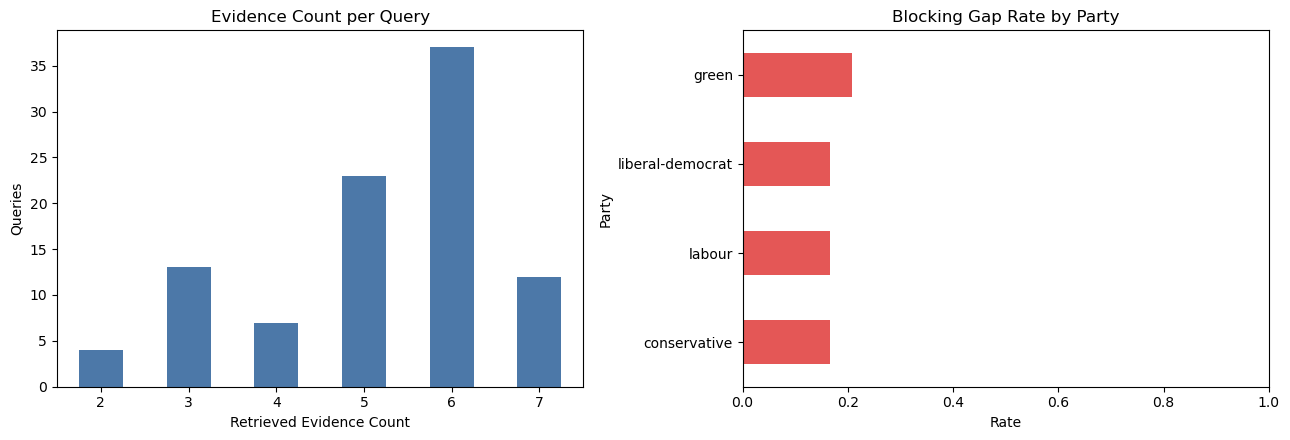

In [14]:
# 绘制每个查询的证据数量和各政党的缺口率。
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

query_metrics_v3['results'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4C78A8'
)
axes[0].set_title('Evidence Count per Query')
axes[0].set_xlabel('Retrieved Evidence Count')
axes[0].set_ylabel('Queries')
axes[0].tick_params(axis='x', rotation=0)

party_gap_rates['blocking_gap_rate'].sort_values().plot(
    kind='barh', ax=axes[1], color='#E45756'
)
axes[1].set_title('Blocking Gap Rate by Party')
axes[1].set_xlabel('Rate')
axes[1].set_ylabel('Party')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 15. Build the final local manual-review queue

队列优先包含P0-P3缺口，再补充每个政党最低证据分数的查询。由于06d不再凑满八条，人工审核行数会少于或等于96。

你不需要自己阅读。运行后把最后的Summary发给我，我会读取队列并判断是否可以进入07。

In [15]:
# 选择缺口查询和低分压力查询，生成最终本地审核队列。
review_query_ids = []

blocking = corpus_gap[corpus_gap['gap_priority'].ne('OK')]
review_query_ids.extend(blocking['query_id'].tolist())

for party in PARTIES:
    desired_queries = 6 if party == 'green' else 2
    already = set(review_query_ids)
    candidates = (
        query_metrics_v3[
            query_metrics_v3['query_party'].eq(party)
            & ~query_metrics_v3['query_id'].isin(already)
        ]
        .sort_values(['results', 'mean_adjusted_score'], na_position='first')
        .head(desired_queries)
    )
    review_query_ids.extend(candidates['query_id'].tolist())

review_query_ids = list(dict.fromkeys(review_query_ids))
manual_review_v3 = retrieval_v3[
    retrieval_v3['query_id'].isin(review_query_ids)
].copy()
manual_review_v3['query_motion_excerpt'] = (
    manual_review_v3['query_motion_text']
    .fillna('')
    .astype(str)
    .str.slice(0, 1200)
)
manual_review_v3['evidence_text_excerpt'] = (
    manual_review_v3['evidence_text']
    .fillna('')
    .astype(str)
    .str.slice(0, 1400)
)
manual_review_v3['manual_relevance'] = ''
manual_review_v3['manual_evidence_role'] = ''
manual_review_v3['manual_notes'] = ''

manual_columns = [
    'query_id', 'query_division_key', 'query_party', 'query_date',
    'query_title', 'query_policy_domain', 'query_readiness',
    'prediction_eligible', 'effective_policy_object',
    'evidence_sufficiency', 'query_motion_excerpt', 'rank',
    'source_type', 'evidence_channel', 'base_score', 'adjusted_score',
    'domain_boost', 'title_overlap', 'direct_legislation_match',
    'evidence_title', 'source_date', 'source_url', 'stance_label',
    'evidence_policy_domain', 'page_number', 'page_column',
    'evidence_text_excerpt', 'manual_relevance',
    'manual_evidence_role', 'manual_notes',
]
manual_review_v3 = manual_review_v3[manual_columns]

print('Manual-review queries:', len(review_query_ids))
print('Manual-review evidence rows:', len(manual_review_v3))
display(manual_review_v3.head(20))

Manual-review queries: 29
Manual-review evidence rows: 129


,query_id,query_division_key,query_party,query_date,query_title,query_policy_domain,query_readiness,prediction_eligible,effective_policy_object,evidence_sufficiency,query_motion_excerpt,rank,source_type,evidence_channel,base_score,adjusted_score,domain_boost,title_overlap,direct_legislation_match,evidence_title,source_date,source_url,stance_label,evidence_policy_domain,page_number,page_column,evidence_text_excerpt,manual_relevance,manual_evidence_role,manual_notes
0,pw-2024-07-23-2-commons__conservative__strict_v3,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,insufficient_query_definition,False,,insufficient_query_definition,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully funded plan, fails to i...",1,manifesto,policy,0.141364,0.146364,0.0,0.083333,False,Conservative and Unionist Party Manifesto 2024 | Page 64,2024-06-11,https://public.conservatives.com/publicweb/GE2024/Accessible-Manifesto/Accessible-PDF-Conservative-Manifesto-2024.pdf,NaN,NaN,64.0,right,"Continue to ringfence agricultural funding\nso it is passed directly on to farming and\nrural communities in Scotland, Wales and\nNorthern Ireland alongside a new UK-wide\n£20 million Farming Innovation Fund.\nIntrod...",,,
1,pw-2024-07-23-2-commons__conservative__strict_v3,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,insufficient_query_definition,False,,insufficient_query_definition,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully funded plan, fails to i...",2,manifesto,policy,0.116091,0.121091,0.0,0.083333,False,Conservative and Unionist Party Manifesto 2024 | Page 76,2024-06-11,https://public.conservatives.com/publicweb/GE2024/Accessible-Manifesto/Accessible-PDF-Conservative-Manifesto-2024.pdf,NaN,NaN,76.0,left,"as carbon capture, ofshore wind, hydrogen\nand tidal, including by providing £15 million\nto support the Energy Transition Zone’s skills\nprogrammes. We will continue laying the\ngroundwork for nuclear projects to be...",,,
2,pw-2024-07-23-2-commons__conservative__strict_v3,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,insufficient_query_definition,False,,insufficient_query_definition,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully funded plan, fails to i...",3,historical_vote,historical,0.167242,0.174742,0.0,0.125000,False,Amendment: Achieving Economic Growth,2022-05-18,None,oppose,economy_finance_business,NaN,None,"Historical parliamentary vote.\nParty: conservative.\nObserved stance: oppose.\nMotion title: Amendment: Achieving Economic Growth.\nMotion text: I beg to move amendment (w), at the end of the Question to add: __ut r...",,,
3,pw-2024-07-23-2-commons__conservative__strict_v3,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,agriculture_food_rural,insufficient_query_definition,False,,insufficient_query_definition,"I beg to move amendment l, at the end of the Question to add: __ut respectfully regret that the Gracious Speech does not commit to boosting defence spending to 2.5% of GDP by 2030 with a fully funded plan, fails to i...",4,historical_vote,historical,0.141612,0.154945,0.0,0.222222,False,"Amendment: Economy, Welfare and Public Services",2024-07-22,None,support,economy_finance_business,NaN,None,"Historical parliamentary vote.\nParty: conservative.\nObserved stance: support.\nMotion title: Amendment: Economy, Welfare and Public Services.\nMotion text: I beg to move an amendment, at the end

## 16. Save outputs and print the review summary

In [16]:
# 保存检索证据、缺口表、代理比较、Green比较和人工审核队列。
retrieval_v3.to_csv(
    AUDIT_V3_DIR / 'retrieval_v3_evidence.csv',
    index=False,
)
query_metrics_v3.to_csv(
    AUDIT_V3_DIR / 'retrieval_v3_query_metrics.csv',
    index=False,
)
rolling_index_audit.to_csv(
    AUDIT_V3_DIR / 'rolling_index_audit.csv',
    index=False,
)
corpus_gap.to_csv(
    AUDIT_V3_DIR / 'corpus_gap_queries.csv',
    index=False,
)
gap_summary.to_csv(
    AUDIT_V3_DIR / 'corpus_gap_summary.csv',
    index=False,
)
v2_v3_comparison.to_csv(
    AUDIT_V3_DIR / 'v2_v3_proxy_comparison.csv'
)
green_paired_v3.to_csv(
    AUDIT_V3_DIR / 'green_paired_v3.csv',
    index=False,
)
party_gap_rates.to_csv(
    AUDIT_V3_DIR / 'party_gap_rates.csv'
)
manual_review_v3.to_csv(
    AUDIT_V3_DIR / 'manual_relevance_review_queue_v3.csv',
    index=False,
)

source_counts = retrieval_v3['source_type'].value_counts().to_string()
result_distribution = (
    query_metrics_v3['results'].value_counts().sort_index().to_string()
)
sufficiency_counts = (
    query_metrics_v3['evidence_sufficiency'].value_counts().to_string()
)
gap_counts = corpus_gap['gap_priority'].value_counts().to_string()

summary_lines = [
    '=== TEMPORAL RETRIEVAL V3 SUMMARY FOR REVIEW ===',
    f'Notebook version: {NOTEBOOK_VERSION}',
    'API calls: 0',
    'LLM calls: 0',
    'Manifesto extraction: bbox-layout, page-aware and column-aware',
    'TF-IDF audit mode: rolling by query date',
    f'Rolling indexes built: {len(rolling_index_audit)}',
    f'Audit divisions: {len(audit_divisions)}',
    f'Audit party queries: {len(query_metrics_v3)}',
    f'Knowledge-base chunks: {len(chunks_v3)}',
    f'Deployment sparse index shape: {deployment_matrix.shape}',
    f'Structural gates: {structural_gates}',
    f'Prediction-eligible query rate: {query_metrics_v3["prediction_eligible"].mean():.3f}',
    f'Sufficient-for-LLM query rate: {query_metrics_v3["evidence_sufficiency"].eq("sufficient_for_llm_review").mean():.3f}',
    f'Mean evidence per query: {query_metrics_v3["results"].mean():.3f}',
    f'Queries with 8 results: {int(query_metrics_v3["results"].eq(8).sum())}',
    f'Historical same-domain rate: {historical_v3["same_domain"].mean():.3f}',
    f'Manual-review queries: {len(review_query_ids)}',
    f'Manual-review evidence rows: {len(manual_review_v3)}',
    'Evidence source counts:',
    source_counts,
    'Results per query:',
    result_distribution,
    'Evidence sufficiency:',
    sufficiency_counts,
    'Corpus-gap priorities:',
    gap_counts,
    'V2 vs V3 relevance proxies:',
    v2_v3_comparison.round(4).to_string(),
    'Green paired evidence comparison:',
    green_paired_v3.round(4).to_string(index=False),
    'Party gap rates:',
    party_gap_rates.round(4).to_string(),
    f'RAG v3 output directory: {RAG_V3_DIR}',
    f'Audit output directory: {AUDIT_V3_DIR}',
    'Next step: manually review v3 evidence, then add only the official sources named by corpus_gap.',
    '=== END TEMPORAL RETRIEVAL V3 SUMMARY ===',
]
summary_text = '\n'.join(summary_lines)
(AUDIT_V3_DIR / 'rag_temporal_retrieval_v3_summary.txt').write_text(
    summary_text,
    encoding='utf-8',
)
print(summary_text)

=== TEMPORAL RETRIEVAL V3 SUMMARY FOR REVIEW ===
Notebook version: 06d-rag-temporal-v3
API calls: 0
LLM calls: 0
Manifesto extraction: bbox-layout, page-aware and column-aware
TF-IDF audit mode: rolling by query date
Rolling indexes built: 17
Audit divisions: 24
Audit party queries: 96
Knowledge-base chunks: 4942
Deployment sparse index shape: (4942, 66486)
Structural gates: {'rolling_idf_temporal_gate': True, 'retrieved_evidence_temporal_gate': True, 'same_division_gate': True, 'duplicate_chunk_gate': True, 'maximum_results_gate': True, 'document_diversity_gate': True}
Prediction-eligible query rate: 0.833
Sufficient-for-LLM query rate: 0.833
Mean evidence per query: 5.167
Queries with 8 results: 0
Historical same-domain rate: 0.310
Manual-review queries: 29
Manual-review evidence rows: 129
Evidence source counts:
source_type
historical_vote    300
manifesto          172
bill_reference      24
Results per query:
results
2     4
3    13
4     7
5    23
6    37
7    12
Evidence sufficie